In [8]:
import os
import random
from PIL import Image
import numpy as np
from imgaug import augmenters as iaa

# Compatibility for very new numpy versions
try:
    np.bool
except Exception:
    np.bool = np.bool_

# -------------------------
# Helper: find starting index for augmented filenames
# -------------------------
def find_start_index(folder_path, prefix="aug_", ext_tuple=(".jpg", ".png", ".jpeg")):
    max_idx = -1
    for fname in os.listdir(folder_path):
        name, ext = os.path.splitext(fname)
        if not ext.lower() in ext_tuple:
            continue
        if name.startswith(prefix):
            try:
                idx = int(name[len(prefix):])
                if idx > max_idx:
                    max_idx = idx
            except Exception:
                pass
    return max_idx + 1

# -------------------------
# Augmenter (PBS-safe, edge padding)
# -------------------------
pbs_augmenter = iaa.Sequential([
    iaa.Fliplr(0.5),
    iaa.Sometimes(0.25, iaa.Flipud(1.0)),
    iaa.Sometimes(0.7, iaa.Affine(
        rotate=(-15, 15),
        shear=(-5, 5),
        scale=(0.92, 1.08),
        translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
        mode='edge'
    )),
    iaa.Sometimes(0.4, iaa.CropAndPad(percent=(-0.03, 0.05), pad_mode='edge')),
    iaa.SomeOf((0, 2), [
        iaa.LinearContrast((0.92, 1.08)),
        iaa.GaussianBlur(sigma=(0.0, 0.8)),
        iaa.Sharpen(alpha=(0.0, 0.18), lightness=(0.92, 1.08))
    ], random_order=True),
    iaa.Sometimes(0.3, iaa.Multiply((0.92, 1.08))),
    iaa.Sometimes(0.1, iaa.AddToHueAndSaturation((-6, 6))),
    iaa.Sometimes(0.08, iaa.AdditiveGaussianNoise(scale=(0, 0.006 * 255))),
    iaa.Sometimes(0.05, iaa.CoarseDropout((0.001, 0.01), size_percent=(0.005, 0.02)))
], random_order=True)

# -------------------------
# Save augmented images
# -------------------------
def save_augmented_images(folder_path, images, augmenter, target_count):
    current_count = len(images)
    to_generate = max(0, target_count - current_count)
    if to_generate == 0:
        return

    image_index = find_start_index(folder_path, prefix="aug_")

    for _ in range(to_generate):
        try:
            img_path = random.choice(images)
            img = Image.open(img_path).convert("RGB")
            img_array = np.array(img)

            augmented = augmenter(image=img_array)
            if augmented is None:
                raise RuntimeError("augmenter returned None")
            if augmented.dtype != np.uint8:
                augmented = np.clip(augmented, 0, 255).astype(np.uint8)

            new_filename = os.path.join(folder_path, f"aug_{image_index}.jpg")
            while os.path.exists(new_filename):
                image_index += 1
                new_filename = os.path.join(folder_path, f"aug_{image_index}.jpg")

            Image.fromarray(augmented).save(new_filename, quality=95)
            image_index += 1
            current_count += 1

        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            try:
                images.remove(img_path)
                if len(images) == 0:
                    print("No more source images available to augment in this folder.")
                    break
            except Exception:
                pass
            continue

# -------------------------
# Main augment_data function
# -------------------------
def augment_data(dataset_path, target_count_per_class, augmenter=pbs_augmenter):
    if not os.path.isdir(dataset_path):
        raise ValueError(f"dataset_path not found: {dataset_path}")

    folders = [d for d in sorted(os.listdir(dataset_path)) if os.path.isdir(os.path.join(dataset_path, d))]
    if not folders:
        print("No subfolders found in dataset_path.")
        return

    for folder in folders:
        folder_path = os.path.join(dataset_path, folder)
        images = [os.path.join(folder_path, f) for f in os.listdir(folder_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        current = len(images)
        if current >= target_count_per_class:
            print(f"'{folder}' already has {current} images. Skipping.")
            continue

        print(f"Augmenting '{folder}': {current} -> {target_count_per_class}")
        save_augmented_images(folder_path, images, augmenter, target_count_per_class)

    print("Data augmentation completed!")


In [7]:
augment_data(r"PBS-3242-Normalized-datasets\E_Separated_Dataset", target_count_per_class = 2000)

Processing class folders:   0%|          | 0/4 [00:00<?, ?it/s, Benign=966]

Augmenting 'Benign': 966 -> 2000


Processing class folders:  25%|██▌       | 1/4 [00:25<01:16, 25.40s/it, [Malignant] Pre-B=985]

Augmenting '[Malignant] Pre-B': 985 -> 2000


Processing class folders:  50%|█████     | 2/4 [00:52<00:53, 26.65s/it, [Malignant] Pro-B=796]

Augmenting '[Malignant] Pro-B': 796 -> 2000


Processing class folders:  75%|███████▌  | 3/4 [01:26<00:29, 29.78s/it, [Malignant] early Pre-B=1288]

Augmenting '[Malignant] early Pre-B': 1288 -> 2000


Processing class folders: 100%|██████████| 4/4 [01:58<00:00, 29.52s/it, [Malignant] early Pre-B=1288]

Data augmentation completed!


In [10]:
augment_data(r"PBS-3242-Normalized-datasets\H_Separated_Dataset", target_count_per_class = 2000)

Augmenting 'Benign': 512 -> 2000
Augmenting '[Malignant] Pre-B': 955 -> 2000
Augmenting '[Malignant] Pro-B': 796 -> 2000
Augmenting '[Malignant] early Pre-B': 979 -> 2000
Data augmentation completed!


In [11]:
augment_data(r"PBS-3242-Normalized-datasets\HE_Normalized_Dataset", target_count_per_class = 2000)

Augmenting 'Benign': 512 -> 2000
Augmenting '[Malignant] Pre-B': 955 -> 2000
Augmenting '[Malignant] Pro-B': 796 -> 2000
Augmenting '[Malignant] early Pre-B': 979 -> 2000
Data augmentation completed!


In [12]:
augment_data(r"PBS-3242-Normalized-datasets\Segmented_Dataset\Masked_Images", target_count_per_class = 2000)

Augmenting 'Benign': 512 -> 2000
Augmenting '[Malignant] Pre-B': 955 -> 2000
Augmenting '[Malignant] Pro-B': 796 -> 2000
Augmenting '[Malignant] early Pre-B': 979 -> 2000
Data augmentation completed!


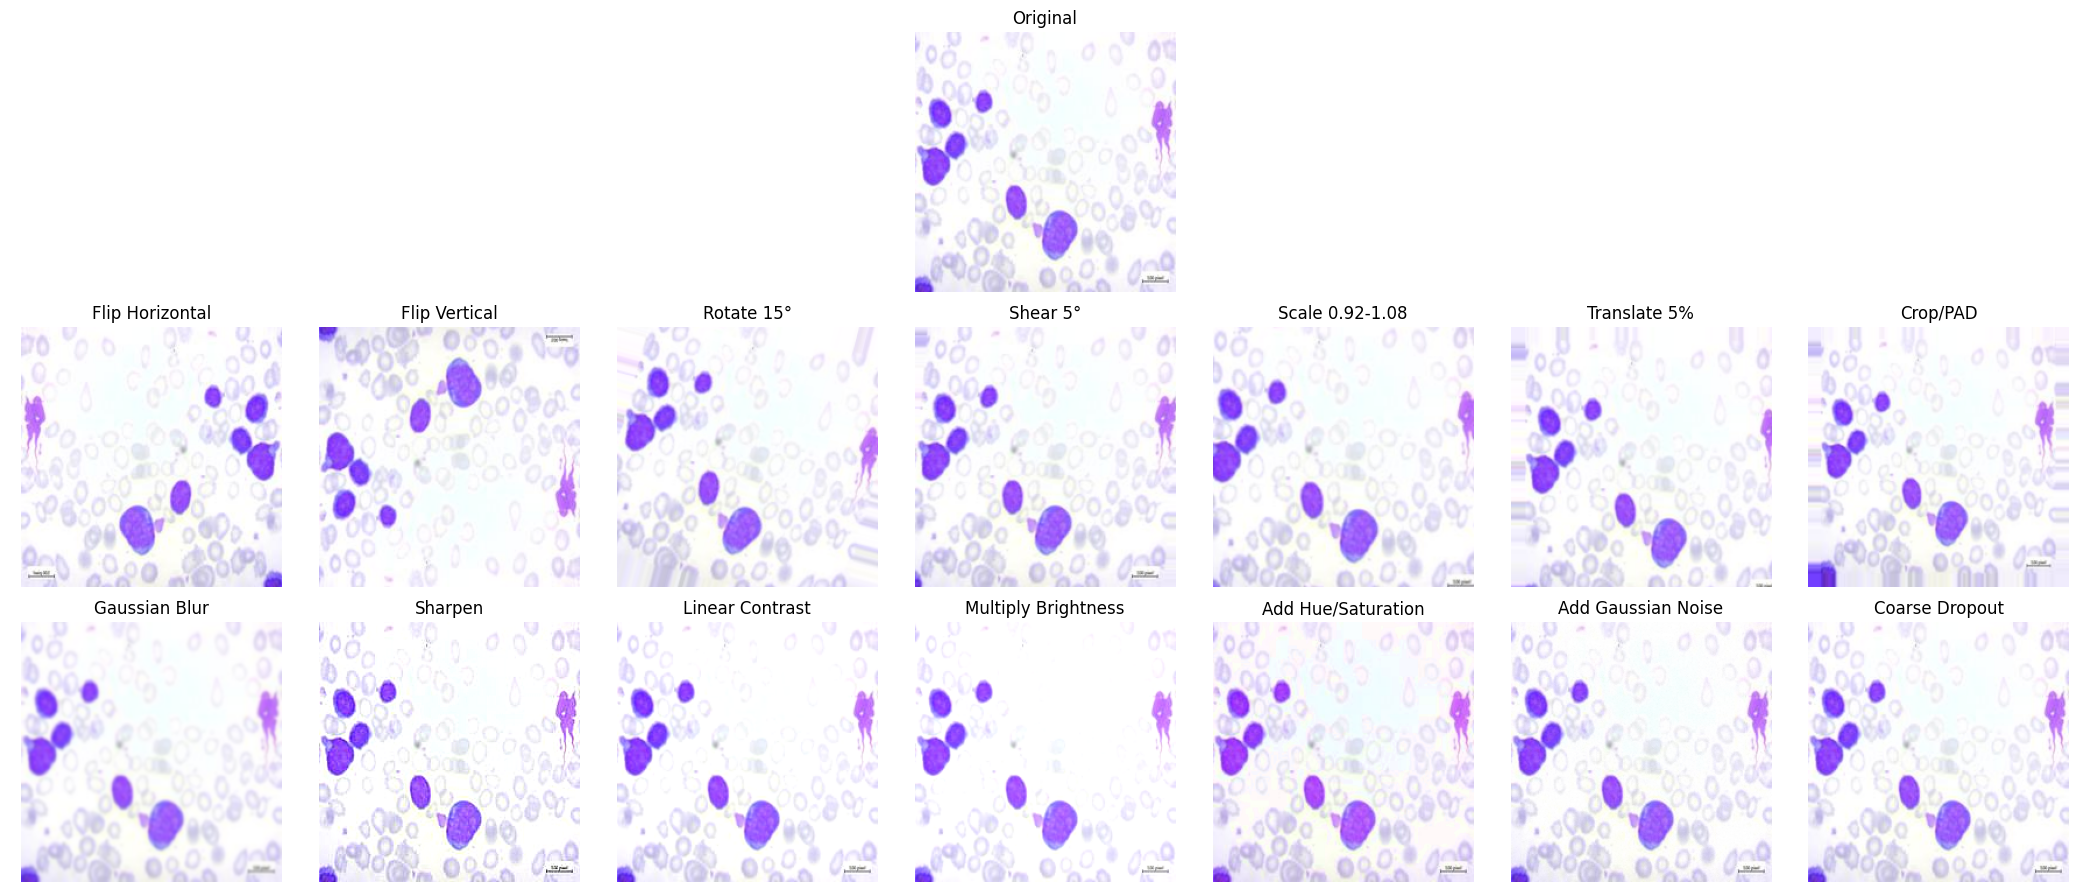

In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from imgaug import augmenters as iaa

def show_all_augmentations_3row7col(img_path):
    img = Image.open(img_path).convert("RGB")
    img_array = np.array(img)

    # Define 14 deterministic augmenters
    augmenters = [
        ("Flip Horizontal", iaa.Fliplr(1.0)),
        ("Flip Vertical", iaa.Flipud(1.0)),
        ("Rotate 15°", iaa.Affine(rotate=15, mode='edge')),
        ("Shear 5°", iaa.Affine(shear=5, mode='edge')),
        ("Scale 0.92-1.08", iaa.Affine(scale=(0.92, 1.08), mode='edge')),
        ("Translate 5%", iaa.Affine(translate_percent={"x":0.05, "y":0.05}, mode='edge')),
        ("Crop/PAD", iaa.CropAndPad(percent=0.05, pad_mode='edge')),
        ("Gaussian Blur", iaa.GaussianBlur(sigma=1.0)),
        ("Sharpen", iaa.Sharpen(alpha=0.18, lightness=1.08)),
        ("Linear Contrast", iaa.LinearContrast(1.08)),
        ("Multiply Brightness", iaa.Multiply(1.08)),
        ("Add Hue/Saturation", iaa.AddToHueAndSaturation(6)),
        ("Add Gaussian Noise", iaa.AdditiveGaussianNoise(scale=0.006*255)),
        ("Coarse Dropout", iaa.CoarseDropout((0.01, 0.02), size_percent=0.02))
    ]

    n_rows, n_cols = 3, 7
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
    axes = axes.flatten()

    # Row 1, Column 1: original image
    axes[3].imshow(img_array)
    axes[3].set_title("Original")
    axes[3].axis("off")

    # Turn off the rest of the first row axes
    for idx in range(0, 3):
        axes[idx].axis("off")
    for idx in range(4, n_cols):
        axes[idx].axis("off")
    # Fill row 2 with first 7 augmentations
    for i in range(7):
        name, aug = augmenters[i]
        aug_img = aug(image=img_array)
        if aug_img.dtype != np.uint8:
            aug_img = np.clip(aug_img, 0, 255).astype(np.uint8)
        axes[n_cols + i].imshow(aug_img)
        axes[n_cols + i].set_title(name)
        axes[n_cols + i].axis("off")

    # Fill row 3 with next 7 augmentations
    for i in range(7, 14):
        name, aug = augmenters[i]
        aug_img = aug(image=img_array)
        if aug_img.dtype != np.uint8:
            aug_img = np.clip(aug_img, 0, 255).astype(np.uint8)
        axes[2*n_cols + (i-7)].imshow(aug_img)
        axes[2*n_cols + (i-7)].set_title(name)
        axes[2*n_cols + (i-7)].axis("off")

    plt.tight_layout()
    plt.show()

# Example usage
sample_image_path = r"C:\Users\Faysal Ahmmed\Desktop\original\original_1.jpg"
show_all_augmentations_3row7col(sample_image_path)
